In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

with open('merged_coco.json') as f:
    data = json.load(f)

EXCLUDE = {'common', 'unlabel'}
cat_map = {c['id']: c['name'] for c in data['categories']}
valid_cat_ids = {c['id'] for c in data['categories'] if c['name'] not in EXCLUDE}
valid_cats = [c for c in data['categories'] if c['name'] not in EXCLUDE]

annotations = [a for a in data['annotations'] if a['category_id'] in valid_cat_ids]
images = data['images']
valid_image_ids = {a['image_id'] for a in annotations}
print(f'Total images       : {len(valid_image_ids)}')
print(f'Valid annotations   : {len(annotations)} ')
print(f'Valid categories    : {[c["name"] for c in valid_cats]}')

Total images 01       : 2811
Total images        : 2855
Valid annotations   : 12906 
Valid categories    : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'single']


## 1. Annotation Count per Category

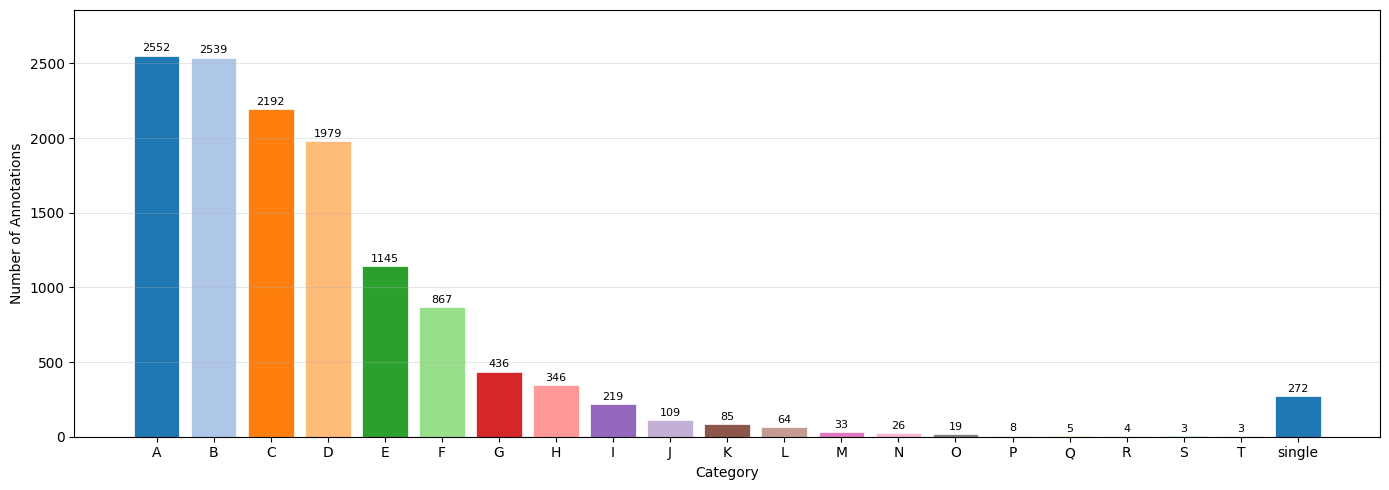

In [6]:
cat_counts = Counter(a['category_id'] for a in annotations)
labels = [c['name'] for c in valid_cats]
counts = [cat_counts.get(c['id'], 0) for c in valid_cats]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels, counts, color=plt.cm.tab20.colors[:len(labels)], edgecolor='white', linewidth=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            str(cnt), ha='center', va='bottom', fontsize=8)
#ax.set_title('Annotation Count per Category (excluding common & unlabel)', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Annotations')
ax.set_ylim(0, max(counts) * 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cat_count.pdf')
plt.show()

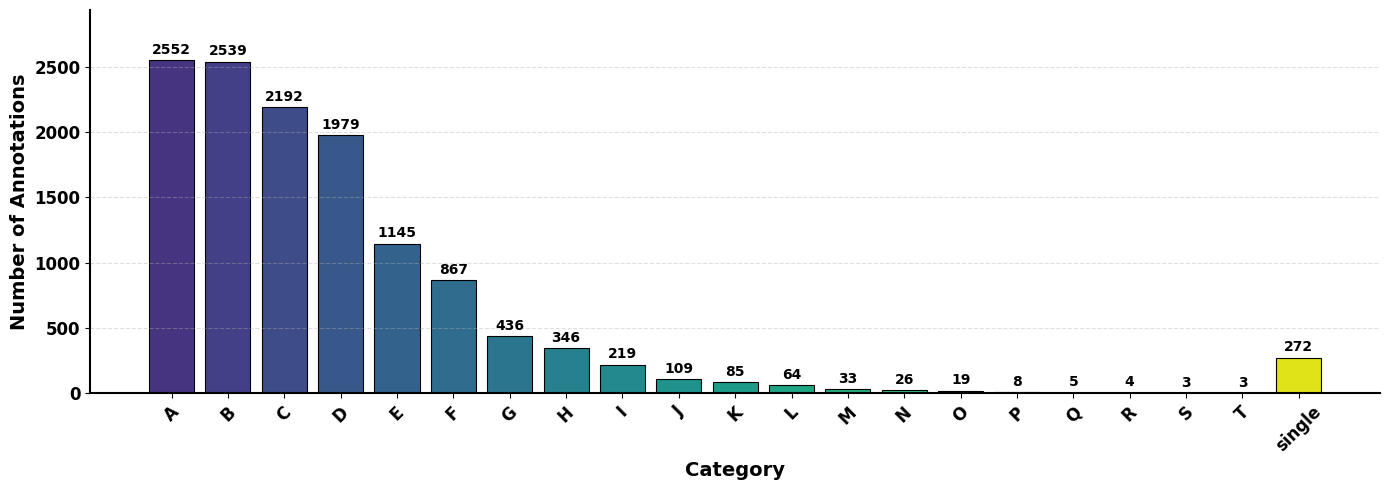

In [12]:
cat_counts = Counter(a['category_id'] for a in annotations)
labels = [c['name'] for c in valid_cats]
counts = [cat_counts.get(c['id'], 0) for c in valid_cats]

#paper color palett
#colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
# Nature-style palette
colors = plt.cm.viridis(
    np.linspace(0.15, 0.95, len(labels))
)
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    labels,
    counts,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Bold numbers above bars
for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(counts)*0.01,
        str(cnt),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Axis labels
ax.set_xlabel(
    'Category',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Annotations',
    fontsize=14,
    fontweight='bold'
)

# Bold tick labels
ax.tick_params(axis='both', labelsize=12)

for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_rotation(45)

for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

# Make axes thicker
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# Vector format preferred for papers
plt.savefig(
    'cat_count.pdf',
    bbox_inches='tight'
)

plt.show()

## 2. Pareto: Cumulative Annotation Coverage

In [ ]:
sorted_pairs = sorted(zip(counts, labels), reverse=True)
sorted_counts = [p[0] for p in sorted_pairs]
sorted_labels = [p[1] for p in sorted_pairs]
cumulative = np.cumsum(sorted_counts) / sum(sorted_counts) * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(sorted_labels, sorted_counts, color='steelblue', alpha=0.7)
ax2.plot(sorted_labels, cumulative, color='firebrick', marker='o', linewidth=2, markersize=4)
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_title('Pareto: Annotation Distribution by Category', fontsize=13, fontweight='bold')
ax1.set_xlabel('Category (sorted by count)')
ax1.set_ylabel('Count')
ax2.set_ylabel('Cumulative %')
ax2.set_ylim(0, 105)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pareto.png', dpi=150)
plt.show()

## 3. Bounding Box Area Distribution per Category

In [ ]:
areas_by_cat = defaultdict(list)
for a in annotations:
    areas_by_cat[cat_map[a['category_id']]].append(a['area'])

plot_cats = [c['name'] for c in valid_cats if len(areas_by_cat[c['name']]) >= 3]
plot_data = [areas_by_cat[c] for c in plot_cats]
colors = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(16, 6))
bp = ax.boxplot(plot_data, labels=plot_cats, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Bounding Box Area Distribution per Category (outliers hidden)', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('BBox Area (px\u00b2)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bbox_area.png', dpi=150)
plt.show()

## 4. Annotations per Image Distribution

In [ ]:
anns_per_image = Counter(a['image_id'] for a in annotations)
counts_per_img = list(anns_per_image.values())
annotated_ids = set(anns_per_image.keys())
all_ids = {img['id'] for img in images}
unannotated = len(all_ids - annotated_ids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(counts_per_img, bins=30, color='teal', edgecolor='white', linewidth=0.5)
axes[0].axvline(np.mean(counts_per_img), color='red', linestyle='--', linewidth=1.2,
                label=f'Mean: {np.mean(counts_per_img):.1f}')
axes[0].axvline(np.median(counts_per_img), color='orange', linestyle='--', linewidth=1.2,
                label=f'Median: {np.median(counts_per_img):.1f}')
axes[0].set_title('Annotations per Image', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Annotations')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].pie(
    [len(annotated_ids), unannotated],
    labels=[f'Annotated ({len(annotated_ids)})', f'No valid annotation ({unannotated})'],
    colors=['teal', 'lightgray'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white')
)
axes[1].set_title('Image Coverage (valid annotations only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ann_per_image.png', dpi=150)
plt.show()
print(f'Mean  : {np.mean(counts_per_img):.2f} | Median: {np.median(counts_per_img):.1f} | Max: {max(counts_per_img)}')

## 5. Category Co-occurrence Heatmap

In [ ]:
cat_names = [c['name'] for c in valid_cats]
cat_id_to_idx = {c['id']: i for i, c in enumerate(valid_cats)}
n = len(cat_names)
cooccur = np.zeros((n, n), dtype=int)

img_cats = defaultdict(set)
for a in annotations:
    img_cats[a['image_id']].add(a['category_id'])

for cats in img_cats.values():
    cats = list(cats)
    for ci in cats:
        for cj in cats:
            cooccur[cat_id_to_idx[ci], cat_id_to_idx[cj]] += 1

diag = np.diag(cooccur).astype(float)
diag[diag == 0] = 1
cooccur_norm = cooccur / diag[:, None]

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cooccur_norm, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='P(col | row)')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(cat_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cat_names, fontsize=9)
ax.set_title('Category Co-occurrence Heatmap\nP(col present | row present in same image)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cooccurrence.png', dpi=150)
plt.show()

## 6. BBox Aspect Ratio (w/h) per Category

In [ ]:
ratios_by_cat = defaultdict(list)
for a in annotations:
    _, _, w, h = a['bbox']
    if h > 0:
        ratios_by_cat[cat_map[a['category_id']]].append(w / h)

ratio_data = [ratios_by_cat[c] for c in plot_cats]

fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(ratio_data, labels=plot_cats, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Square (w=h)')
ax.set_title('BBox Aspect Ratio (w/h) per Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Aspect Ratio (w / h)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('aspect_ratio.png', dpi=150)
plt.show()